In [7]:
import pandas as pd

# Load Excel dataset
df = pd.read_excel("cam-key-data.xlsx")

pd.set_option('display.max_rows', 5)
display(df.head(5))

# Convert wide format to long format
df_long = df.melt(
    id_vars=["Country Name", "Country Code", "Indicator Name", "Indicator Code"],
    var_name="Year",
    value_name="Value"
)

# Convert Year to numeric
df_long["Year"] = pd.to_numeric(df_long["Year"], errors="coerce")

# Sort values
df_long = df_long.sort_values(["Indicator Name", "Year"])

# Save cleaned dataset
df_long.to_csv("cambodia_cleaned_data.csv", index=False)

# Load the cleaned dataset
df = pd.read_csv("cambodia_cleaned_data.csv")

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
0,Cambodia,KHM,"Internally displaced persons, new displacement...",VC.IDP.NWDS,NaN,NaN,NaN,NaN,NaN,NaN,...,8.300000e+03,1.500000e+04,3.700000e+04,7.000000e+04,6.600000e+04,1.500000e+04,2.800000e+04,4.600000e+04,NaN,NaN
1,Cambodia,KHM,"Voice and Accountability: Percentile Rank, Upp...",VA.PER.RNK.UPPER,NaN,NaN,NaN,NaN,NaN,NaN,...,2.315271e+01,2.266010e+01,1.990291e+01,2.077295e+01,1.690821e+01,1.497585e+01,1.884058e+01,1.911765e+01,NaN,NaN
2,Cambodia,KHM,Voice and Accountability: Estimate,VA.EST,NaN,NaN,NaN,NaN,NaN,NaN,...,-1.105503e+00,-1.155112e+00,-1.232996e+00,-1.220067e+00,-1.357136e+00,-1.433813e+00,-1.309937e+00,-1.292422e+00,NaN,NaN
3,Cambodia,KHM,High-technology exports (current US$),TX.VAL.TECH.CD,NaN,NaN,NaN,NaN,NaN,NaN,...,1.711160e+08,1.772053e+08,1.648160e+08,1.603724e+08,3.084243e+08,4.549082e+08,1.225958e+09,2.353434e+09,1.095669e+09,NaN
4,Cambodia,KHM,Merchandise exports to low- and middle-income ...,TX.VAL.MRCH.WR.ZS,6.034483,5.565863,10.721649,4.584527,19.307832,18.181818,...,1.429349e+01,1.567745e+01,1.360686e+01,1.407968e+01,1.897005e+01,2.282549e+01,2.008738e+01,2.456119e+01,NaN,NaN


In [8]:
import pandas as pd

# 1️⃣ Load the dataset
df = pd.read_csv("cambodia_cleaned_data.csv")

                # Data Cleaning

# 2️⃣ Inspect the data
print(df.info())
print(df.isnull().sum())

# 3️⃣ Drop unnecessary columns
df = df.drop(columns=["Country Code", "Indicator Code"])

# 4️⃣ Drop rows with missing values in the "Value" column
df = df.dropna(subset=["Value"])

# 5️⃣ Data type conversion
df["Year"] = df["Year"].astype(int)
df["Value"] = df["Value"].astype(float)

# 6️⃣ Rename columns for clarity
df = df.rename(columns={
    "Country Name": "Country",
    "Indicator Name": "Indicator",
    "Year": "Year",
    "Value": "Value"
})

                # Feature Creation

# 7️⃣ Filter for important indicators
important_indicators = [
    "Population growth (annual %)",
    "GDP growth (annual %)",
    "Inflation, consumer prices (annual %)"
]
df = df[df["Indicator"].isin(important_indicators)]

# 8️⃣ Filter for Cambodia only (optional if dataset has other countries)
df = df[df["Country"] == "Cambodia"]

                        # Feature Engineering

# 9️⃣ Pivot the dataset to wide format (ML-ready)
pivot_df = df.pivot(index="Year", columns="Indicator", values="Value")
pivot_df.reset_index(inplace=True)

# 1️⃣0️⃣ Optional: remove duplicate rows
pivot_df = pivot_df.drop_duplicates()

# 1️⃣1️⃣ Save the cleaned & pivoted CSV
pivot_df.to_csv("cambodia_cleaned_wide.csv", index=False)

# 1️⃣2️⃣ Load the cleaned CSV and set display options
df = pd.read_csv("cambodia_cleaned_wide.csv")
pd.set_option('display.max_rows', 1000)

# 1️⃣3️⃣ Display first 10 rows
display(df.head(100))

print("✅ Data cleaning, filtering, and pivoting complete!")

<class 'pandas.DataFrame'>
RangeIndex: 100056 entries, 0 to 100055
Data columns (total 6 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   Country Name    100056 non-null  str    
 1   Country Code    100056 non-null  str    
 2   Indicator Name  100056 non-null  str    
 3   Indicator Code  100056 non-null  str    
 4   Year            100056 non-null  int64  
 5   Value           37008 non-null   float64
dtypes: float64(1), int64(1), str(4)
memory usage: 4.6 MB
None
Country Name        0
Country Code        0
                ...  
Year                0
Value           63048
Length: 6, dtype: int64


,Year,GDP growth (annual %),"Inflation, consumer prices (annual %)",Population growth (annual %)
0,1961,NaN,NaN,2.199536
1,1962,NaN,NaN,2.243294
2,1963,NaN,NaN,2.177965
3,1964,NaN,NaN,2.093135
4,1965,NaN,NaN,2.098697
5,1966,NaN,NaN,2.101235
6,1967,NaN,NaN,2.101723
7,1968,NaN,NaN,2.099721
8,1969,NaN,NaN,2.102288
9,1970,NaN,NaN,0.520346


✅ Data cleaning, filtering, and pivoting complete!


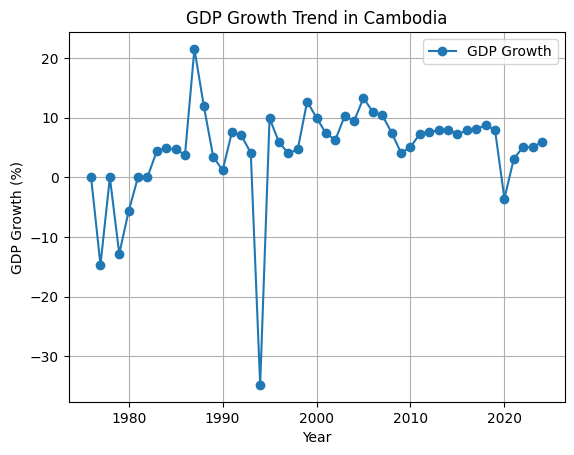

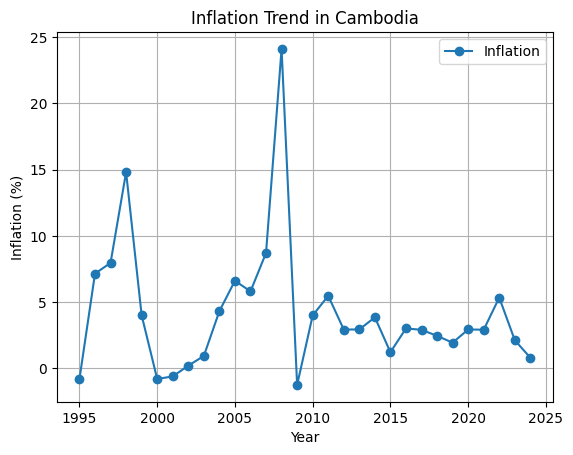

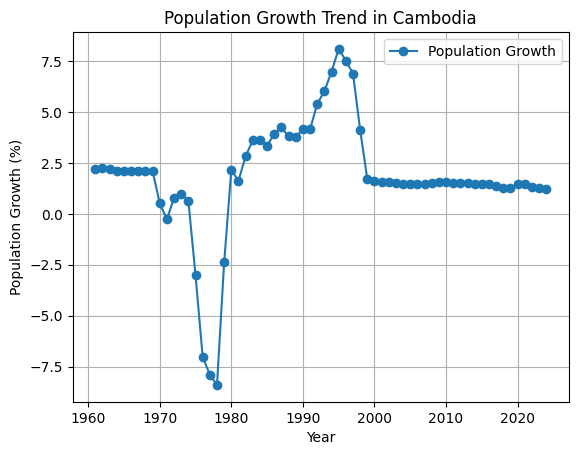

In [9]:
import matplotlib.pyplot as plt

# GDP Growth
plt.figure()
plt.plot(df["Year"], df["GDP growth (annual %)"], marker='o', label="GDP Growth")
plt.title("GDP Growth Trend in Cambodia")
plt.xlabel("Year")
plt.ylabel("GDP Growth (%)")
plt.legend()
plt.grid(True)
plt.show()

# Inflation
plt.figure()
plt.plot(df["Year"], df["Inflation, consumer prices (annual %)"], marker='o', label="Inflation")
plt.title("Inflation Trend in Cambodia")
plt.xlabel("Year")
plt.ylabel("Inflation (%)")
plt.legend()
plt.grid(True)
plt.show()

# Population Growth
plt.figure()
plt.plot(df["Year"], df["Population growth (annual %)"], marker='o', label="Population Growth")
plt.title("Population Growth Trend in Cambodia")
plt.xlabel("Year")
plt.ylabel("Population Growth (%)")
plt.legend()
plt.grid(True)
plt.show()

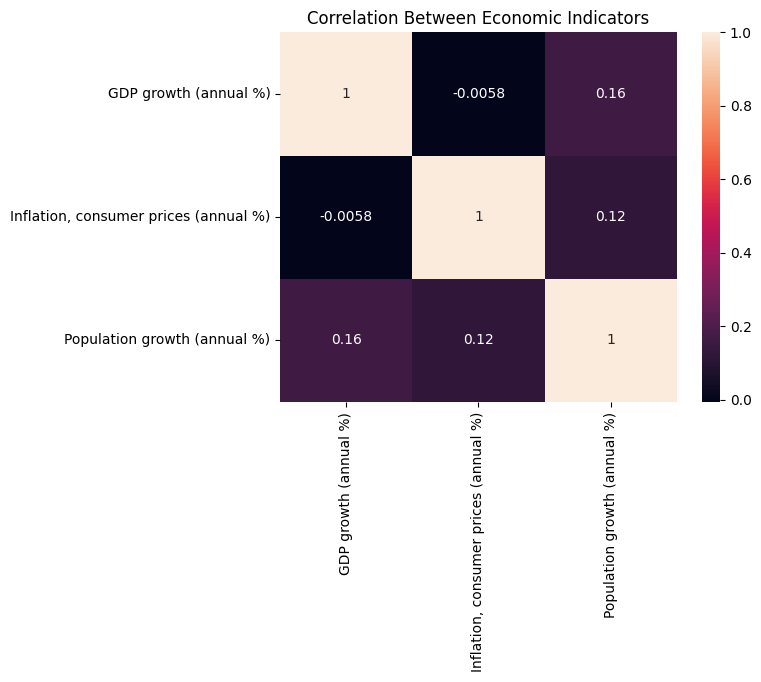

In [10]:
import seaborn as sns

corr = df[[
    "GDP growth (annual %)",
    "Inflation, consumer prices (annual %)",
    "Population growth (annual %)"
]].corr()

plt.figure()
sns.heatmap(corr, annot=True)
plt.title("Correlation Between Economic Indicators")
plt.show()

In [11]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Load dataset
df = pd.read_csv("cambodia_cleaned_wide.csv")

# Handle missing values
df = df.dropna()

# Features
X = df[[
    "Population growth (annual %)",
    "Inflation, consumer prices (annual %)"
]]

# Target
y = df["GDP growth (annual %)"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [12]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

In [13]:
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

In [14]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

In [15]:
from sklearn.svm import SVR

svr = SVR()
svr.fit(X_train, y_train)

svr_pred = svr.predict(X_test)

In [16]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

def evaluate_model(y_test, pred):
    mae = mean_absolute_error(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    r2 = r2_score(y_test, pred)
    
    return mae, rmse, r2

# Evaluate models
lr_results = evaluate_model(y_test, lr_pred)
dt_results = evaluate_model(y_test, dt_pred)
rf_results = evaluate_model(y_test, rf_pred)
svr_results = evaluate_model(y_test, svr_pred)

# Create comparison table
results_table = pd.DataFrame({
    "Model": ["Linear Regression", "Decision Tree", "Random Forest", "SVR"],
    "MAE": [lr_results[0], dt_results[0], rf_results[0], svr_results[0]],
    "RMSE": [lr_results[1], dt_results[1], rf_results[1], svr_results[1]],
    "R2 Score": [lr_results[2], dt_results[2], rf_results[2], svr_results[2]]
})

# Round values for cleaner display
results_table = results_table.round(2)

print(results_table)

               Model   MAE  RMSE  R2 Score
0  Linear Regression  1.93  2.10     -0.08
1      Decision Tree  5.20  6.22     -8.52
2      Random Forest  3.56  3.95     -2.83
3                SVR  1.97  2.30     -0.30


1️⃣ Understanding the Metrics
MAE (Mean Absolute Error)

Measures the average absolute difference between predicted and actual GDP growth.

Lower MAE = predictions are closer to real values.
Example: MAE = 1.93 for Linear Regression → on average, predictions are off by 1.93% GDP growth.
RMSE (Root Mean Squared Error)
Measures error while penalizing larger mistakes more than smaller ones.

Lower RMSE = better model.
Example: RMSE = 2.10 for Linear Regression → typical prediction errors are around 2.1%.
RMSE > MAE often indicates that some predictions are far from actual values.
R² Score (Coefficient of Determination)
Measures how much of the variation in GDP growth the model explains.

Range:

1 → perfect prediction
0 → model predicts no better than the mean
< 0 → model is worse than predicting the mean
Interpretation of your R² values:

Model	R²	Meaning
Linear Regression	-0.08	Slightly worse than predicting the mean
Decision Tree	-8.52	Very poor; predictions do not follow trends
Random Forest	-2.83	Poor; better than Decision Tree but still unreliable
SVR	-0.30	Slightly worse than Linear Regression

Negative R² occurs because the model cannot capture the relationship properly with the current features.

2️⃣ Model-by-Model Analysis
Linear Regression

MAE = 1.93, RMSE = 2.10, R² = -0.08
Best model in terms of errors (MAE and RMSE are lowest).
Although R² is slightly negative, it still produces more stable and reliable predictions compared to other models.
Interpretation: Simple linear relationships between GDP, population growth, and inflation exist, but they are not strong enough to explain all variation in GDP.

Decision Tree
MAE = 5.20, RMSE = 6.22, R² = -8.52
Very high error → model predictions are often far from actual GDP values.
Large negative R² → the model is overfitting on a small dataset (it memorized patterns in training but failed on test data).

Random Forest
MAE = 3.56, RMSE = 3.95, R² = -2.83
Improves over a single decision tree (averaging reduces overfitting), but still not accurate enough.
Negative R² indicates that the features alone are insufficient to predict GDP well.
SVR (Support Vector Regression)
MAE = 1.97, RMSE = 2.30, R² = -0.30
Performs similar to Linear Regression in terms of MAE and RMSE.
Slightly worse than Linear Regression because the model is sensitive to small datasets and hyperparameters may not be tuned.

3️⃣ Key Takeaways

Linear Regression performed best among the models.
MAE and RMSE indicate that on average, GDP predictions are within 2% of actual growth, which is decent for a small dataset.

Negative R² means:
The selected features (population growth and inflation) cannot fully explain GDP growth.
Other economic indicators like investment, trade, government spending, exports, or FDI are likely needed.
Decision Tree and Random Forest performed poorly due to overfitting and small dataset size.
SVR is close to Linear Regression, but Linear Regression is simpler and slightly better for this dataset.

4️⃣ How to Explain in a Report

The regression models were evaluated using MAE, RMSE, and R² score. Linear Regression achieved the lowest prediction errors (MAE = 1.93, RMSE = 2.10) and was therefore the most reliable model among the tested algorithms. Decision Tree and Random Forest models showed higher errors and very low R² values, indicating overfitting and poor prediction ability. SVR performed similarly to Linear Regression but slightly worse. Overall, the negative R² scores suggest that population growth and inflation alone are insufficient to fully explain Cambodia’s GDP growth trends. Adding more economic indicators could improve model performance.